## 2.1 양자 푸리에 변환 (Quantum Fourier Transform, QFT)

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# QFT를 적용하는 함수
def apply_qft(circuit, n):
    """회로의 앞쪽 n개 큐비트에 QFT 적용"""
    for j in range(n):
        for k in range(j):
            circuit.cp(np.pi/2**(j-k), k, j)   # 제어 위상 회전(거리에 따라 각도 절반씩 감소)
        circuit.h(j)                            # 하다마드

In [3]:
# 역QFT를 적용하는 함수
def apply_inverse_qft(circuit, n):
    """회로의 앞쪽 n개 큐비트에 역QFT 적용"""
    for j in range(n//2):
        circuit.swap(j, n-1-j)                  # 큐비트 순서 뒤집기
    for j in reversed(range(n)):
        circuit.h(j)
        for k in reversed(range(j)):
            circuit.cp(-np.pi/2**(j-k), k, j)   # 음의 각도(역회전)

In [4]:
# 양자 회로 생성
num_qubits = 3
qc = QuantumCircuit(num_qubits)

In [5]:
# 하다마드 게이트로 큐비트를 중첩 상태로 초기화
qc.h(range(num_qubits))

In [6]:
# QFT 적용
apply_qft(qc, num_qubits)

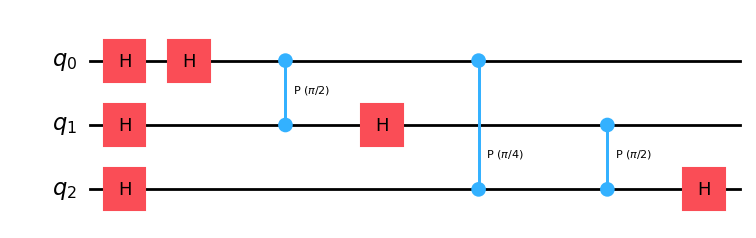

In [7]:
# QFT 적용 후 회로 그리기
qc.draw('mpl')
plt.show()

In [8]:
# 정확성 확인을 위해 역QFT 적용 (QFT∘역QFT = 항등연산)
apply_inverse_qft(qc, num_qubits)

In [9]:
# 큐비트 측정
qc.measure_all()

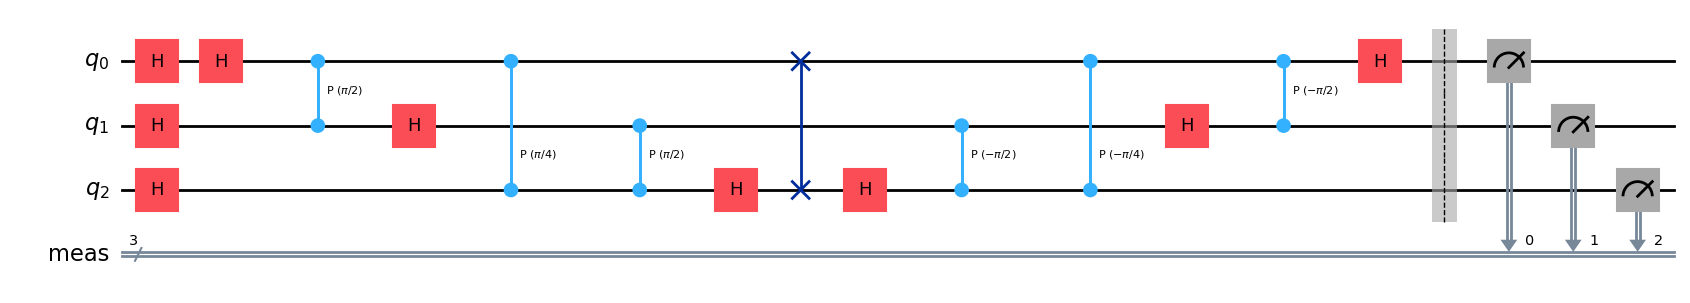

In [10]:
# 최종 회로 그리기
qc.draw('mpl')
plt.show()

In [11]:
# 시뮬레이터 초기화
simulator = AerSimulator()

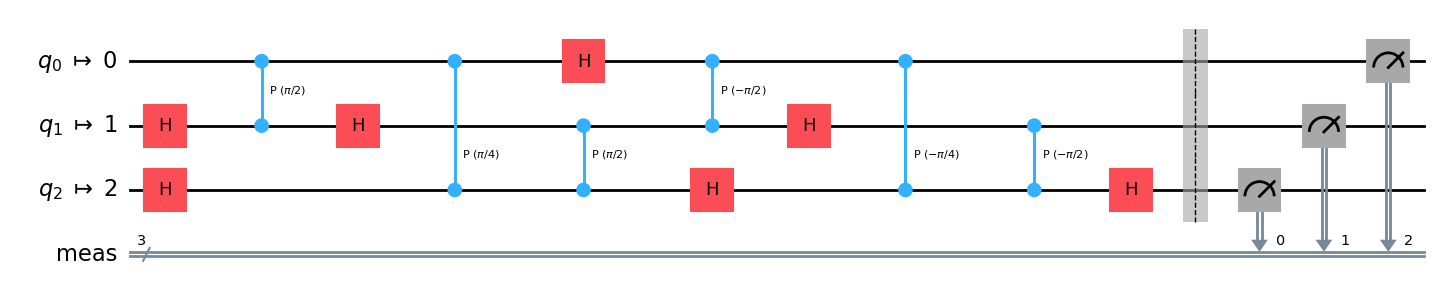

In [12]:
# 회로를 시뮬레이터용으로 트랜스파일하고 실행
compiled_circuit = transpile(qc, simulator)
# 트랜스파일된 회로 그리기
compiled_circuit.draw('mpl')
plt.show()

result = simulator.run(compiled_circuit).result()

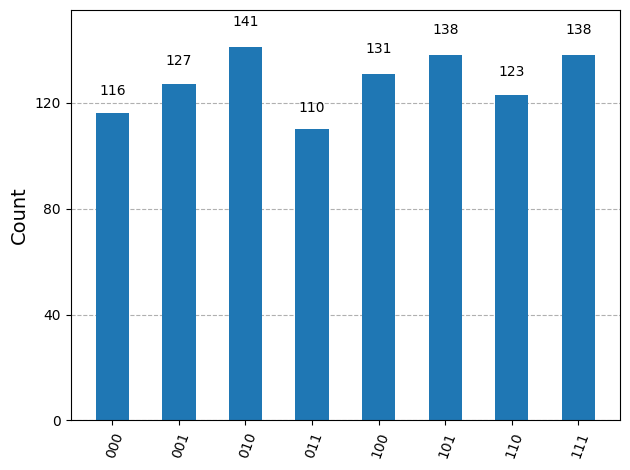

In [13]:
# 결과를 얻어 시각화 (QFT 후 역QFT → 원래 균등 중첩 복원)
counts = result.get_counts(qc)
plot_histogram(counts)
plt.show()